# L6b Advanced: Estimation Risk in Mean-Variance Optimization

In the [frontier-geometry example](../frontier-geometry/CHEME-5660-L6a-Advanced-FrontierGeometry-Fall-2026.ipynb),
we treated the estimated mean growth rates and covariance as fixed inputs. Here
we examine __estimation risk__: how uncertainty in those estimates changes the
optimized portfolio weights. We repeatedly resample the 2014–2024 daily growth
observations for the same thirteen firms, estimate the inputs again, and compare
the resulting allocations. We then apply the long-only allocations to the same
observed 2025 price history to see how their different weights affect wealth.

> __Learning Objectives:__
>
> By the end of this example, you should be able to:
> - **Quantify uncertainty in the inputs:** Use bootstrap resamples of complete daily growth-rate vectors to estimate uncertainty in mean growth rates and growth-rate standard deviations. Explain the assumption introduced by resampling days independently.
> - **Measure portfolio sensitivity:** Compare global minimum-variance (GMV) and tangent allocations with and without short positions, checking the conditions for the closed-form tangent solution. Vary the mean vector and covariance separately to examine sensitivity to each input.
> - **Interpret differences in realized wealth:** Evaluate the resampled long-only allocations on 2025 prices alongside portfolios fitted to all the training data, equal weights, and SPY. Distinguish the effects of changing the estimated weights from uncertainty in future market prices.

We organize the example into three tasks: resample the inputs, compare the
frontiers and weight sensitivity, and evaluate the resulting long-only portfolios
using 2025 prices.

Let's get started!

___


## Setup, Data, and Prerequisites
First, we load the local [`Include.jl`](Include.jl) setup file and its required packages.

> __Include:__ The [`include(...)` command](https://docs.julialang.org/en/v1/base/base/#include) evaluates [`Include.jl`](Include.jl) in the notebook's global scope. The setup file activates the course project and loads the packages and local portfolio functions used here.

Let's set up our code environment:


In [1]:
# Activate the course environment and load packages plus the documented local portfolio helpers.
include(joinpath(@__DIR__, "Include.jl")); # Load the local setup file.

  Activating 

project at `~/Desktop/julia_work/CHEME-5660-CourseRepository-Fall-2026`


See the [Julia documentation](https://docs.julialang.org/en/v1/) and the [CHEME 5660 Quantitative Finance Package documentation](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/) for the functions and types used here.

Let's set the plotting defaults and the random seed used for the bootstrap resamples:


In [2]:
# Apply common figure styling; the seed fixes resamples when cells run in the same order.
default(
    fontfamily = "Helvetica",
    framestyle = :box,
    background_color = :gray97,
    background_color_outside = :white,
    legend_background_color = nothing,
    linewidth = 2,
);
Random.seed!(5660); # reproducible resamples

### Data
We use the training price histories from January 3, 2014 through December 31, 2024 to estimate the portfolio inputs. The testing histories contain the 2025 prices that we use later to evaluate the resulting allocations. We use each day's __volume-weighted average price (VWAP)__ as our share-price observation. It averages transaction prices using the number of shares traded as weights and is stored in the `volume_weighted_average_price` column.

Let's load the two datasets using [the `MyTrainingMarketDataSet()` function](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/data/#VLQuantitativeFinancePackage.MyTrainingMarketDataSet) and [the `MyTestingMarketDataSet()` function](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/data/#VLQuantitativeFinancePackage.MyTestingMarketDataSet). Some tickers have shorter histories than others. Within each dataset, we retain tickers with the same number of price records as `AAPL`, our reference for a full history. The retained price tables are stored in `training_dataset::Dict{String,DataFrame}` and `testing_dataset::Dict{String,DataFrame}`:


In [ ]:
training_dataset, testing_dataset = let
    # Load the training and testing price histories -
    training = MyTrainingMarketDataSet()["dataset"];
    testing = MyTestingMarketDataSet()["dataset"];
    training_length = nrow(training["AAPL"]); # reference training-history length
    testing_length = nrow(testing["AAPL"]); # reference testing-history length

    # Retain complete histories within each dataset -
    # Screen each period separately: the two periods contain different numbers of trading days.
    # This checks record counts; the calculations assume the retained firms have aligned dates.
    training_complete = Dict(
        ticker => prices for (ticker, prices) ∈ training
        if nrow(prices) == training_length
    );
    testing_complete = Dict(
        ticker => prices for (ticker, prices) ∈ testing
        if nrow(prices) == testing_length
    );
    (training_complete, testing_complete);
end;

### Firms and constants
We use the same thirteen firms as the [L6a minimum-variance example](../../CHEME-5660-L6a-Example-Data-MinVar-Portfolio-Fall-2026.ipynb). This set was chosen without using the 2025 outcomes. The ticker order will be the column order of the growth and price matrices and the asset order of the portfolio weights.

We set the observation interval to $\Delta t=1/252$ years and retain the example's risk-free growth-rate benchmark, $g_f=0.041$ inverse years. We store the number of firms in `M::Int64`:


In [ ]:
# The ticker order connects every weight to the same column in growth and price matrices.
# Use the same annual time units for the observed rates and the risk-free benchmark.
my_list_of_tickers = [
    "AAPL", "MSFT", "INTC", "MU", "AMD", "NVDA", "GS",
    "BAC", "WFC", "C", "F", "GM", "JNJ",
]; # firm order used throughout the portfolio calculations
Δt = 1.0/252.0; # one trading day (units: years)
g_f = 0.041; # risk-free growth-rate benchmark (units: inverse years)
M = length(my_list_of_tickers); # number of selected firms

### Construct the growth observations
We convert the selected firms' training prices into growth rates using [the `log_growth_matrix(...)` function](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/equity/#VLQuantitativeFinancePackage.log_growth_matrix). If $S_{k-1}^{(i)}$ and $S_k^{(i)}$ are successive price observations for firm $i$, its growth rate over interval $k$ is given by:
$$
g_k^{(i)}=\frac{1}{\Delta t}\ln\!\left(\frac{S_k^{(i)}}{S_{k-1}^{(i)}}\right),
\qquad k=1,\ldots,N,\quad i=1,\ldots,M.
$$
With $N+1$ aligned price records, we obtain $N$ growth observations per firm. We collect them in $\mathbf{G}\in\mathbb{R}^{N\times M}$, stored in `G::Array{Float64,2}`, with units of inverse years. Each row contains all firms' growth rates over one common interval, and each column contains one firm's growth history. This row structure matters: resampling a complete row keeps the firms' same-day observations together.

Let's construct `G` and count its rows:


In [ ]:
# Compute log(S[k+1]/S[k])/Δt for each firm. N + 1 prices give N interval observations.
# A complete row contains simultaneous growth rates and is the unit resampled below.
G = log_growth_matrix(training_dataset, my_list_of_tickers, Δt = Δt); # N × M, inverse years
N = size(G, 1); # number of training growth observations per firm

### Keep the 2025 prices for the wealth comparison
We also collect the selected firms' 2025 prices in `prices_2025::Array{Float64,2}`, with trading days in rows and firms in the same column order as `G`. The `spy_2025::Array{Float64,1}` vector holds the corresponding SPY prices for the index-fund comparison. The wealth calculation will divide each price history by its first observed price:


In [ ]:
# hcat joins the selected price vectors as columns, preserving the chosen ticker order.
# The first price row sets purchase prices; subsequent rows value the fixed holdings.
prices_2025 = hcat([
    testing_dataset[ticker][:, :volume_weighted_average_price]
    for ticker ∈ my_list_of_tickers
]...); # 2025 price matrix (units: USD per share)
spy_2025 = testing_dataset["SPY"][:, :volume_weighted_average_price]; # SPY prices, USD per share

Let's report the number of training growth observations, selected firms, and 2025 price records before estimating the portfolio inputs:


In [ ]:
# Report dimensions before fitting: growth observations count intervals, whereas prices count dates.
println("Training growth observations per firm: $(N)")
println("Selected firms: $(M)")
println("2025 price records per firm: $(size(prices_2025, 1))")

### Estimate the portfolio inputs
The portfolio calculations need the mean growth rate of each firm and the covariance of their growth rates. We first estimate these quantities using all $N$ training observations. These __point estimates__ provide the baseline for the bootstrap comparisons.

Following L5a and the L6a examples, we estimate each firm's mean growth rate by averaging its column of $\mathbf{G}$. For firm $i$, the sample mean is given by:
$$
g_i^{\prime}=\frac{1}{N}\sum_{k=1}^{N}g_k^{(i)},
\qquad i=1,\ldots,M.
$$
Collecting these values gives the sample-mean vector $\mathbf{g}^{\prime}$, which estimates the population mean-growth vector $\boldsymbol{\mu}_g$. We store it in `ĝ₀::Array{Float64,1}`; both the sample means and population means have units of inverse years.

To estimate covariance, we subtract each firm's sample mean from its growth observations. This gives the centered matrix $\tilde{\mathbf{G}}$, with entry $g_k^{(i)}-g_i^{\prime}$ in row $k$, column $i$. For $N\geq2$, the sample covariance is given by:
$$
\hat{\mathbf{\Sigma}}_g=\frac{1}{N-1}\tilde{\mathbf{G}}^{\top}\tilde{\mathbf{G}}.
$$
The diagonal entries estimate each firm's growth-rate variance, and the off-diagonal entries estimate how pairs of firms' growth rates vary together. All entries have units of inverse years squared. We store this matrix in `Σ̂₀::Array{Float64,2}`. The subscript `₀` in the Julia variable names identifies estimates fitted to all the training observations; later, we compare them with estimates from resampled data.

[The `mean(...)` function](https://docs.julialang.org/en/v1/stdlib/Statistics/#Statistics.mean) averages each column, and [the `cov(...)` function](https://docs.julialang.org/en/v1/stdlib/Statistics/#Statistics.cov) performs the centering and covariance calculation. We use `dims = 1` because observations run down the rows. The closed-form portfolio weights require a positive-definite covariance matrix, which we check using [the `isposdef(...)` function](https://docs.julialang.org/en/v1/stdlib/LinearAlgebra/#LinearAlgebra.isposdef):


In [ ]:
# Estimate the mean growth rates and growth-rate covariance from all training rows -
# Average down each column; vec turns the resulting 1 × M array into a length-M vector.
# cov centers each column and divides by N - 1; this is growth covariance, not Δt-scaled covariance rate.
ĝ₀ = vec(mean(G, dims = 1)); # sample-mean vector g′ (units: inverse years)
Σ̂₀ = cov(G, dims = 1); # sample covariance Σ̂_g (units: inverse years squared)

# Check the covariance condition needed by the closed-form portfolio weights -
@assert isposdef(Σ̂₀)

### Portfolio weights with short positions allowed
We will compare four allocations: global minimum-variance (GMV) and tangent
portfolios, each with and without short positions. We first recall the
[lecture's closed-form weights](../../CHEME-5660-L6a-Lecture-MAGBM-Data-Portfolios-Fall-2026.ipynb)
and substitute the estimated inputs $\mathbf{g}^{\prime}$ and
$\hat{\mathbf{\Sigma}}_g$.

With short positions allowed, the GMV portfolio minimizes growth-rate variance
subject only to the budget constraint. Its weights are given by:
$$
\mathbf{w}_{\mathrm{GMV}}
=\frac{\hat{\mathbf{\Sigma}}_g^{-1}\mathbf{1}}
{\mathbf{1}^{\top}\hat{\mathbf{\Sigma}}_g^{-1}\mathbf{1}}.
$$
Here $\mathbf{1}\in\mathbb{R}^M$ is the vector of ones. The denominator makes
the weights sum to one; individual weights may be negative. These weights
depend on covariance alone, so uncertainty in the estimated means does not
enter this calculation.

The tangent calculation also uses the estimated excess growth above the
risk-free benchmark $g_f$. We first solve for a direction $\mathbf{x}$ and
then calculate the sum of its components, $\kappa$:
$$
\mathbf{x}=\hat{\mathbf{\Sigma}}_g^{-1}
(\mathbf{g}^{\prime}-g_f\mathbf{1}),
\qquad
\kappa=\mathbf{1}^{\top}\mathbf{x}.
$$
For $\kappa\ne0$, the normalized weights are given by:
$$
\mathbf{w}_{\mathrm{norm}}=\frac{\mathbf{x}}{\kappa}.
$$
Both $\mathbf{x}$ and $\kappa$ have units of years, so the weights are
dimensionless. If $\kappa>0$, these are the maximum-Sharpe tangent weights.
If $\kappa<0$, normalization reverses the direction and produces the
minimum-Sharpe allocation. If $\kappa=0$, the direction cannot be normalized
to a fully invested portfolio. A small nonzero $\kappa$ can give large positive
and negative weights; we retain these cases to examine sensitivity.

[The `gmv_closed(...)` function](docs/estimation-risk.md#gmv_closed) and
[the `tangent_closed(...)` function](docs/estimation-risk.md#tangent_closed)
implement these expressions using linear solves. The second function receives
$g_f$ explicitly and retains negative normalizers for the later diagnostic.
The helpers are documented in [src/EstimationRisk.jl](src/EstimationRisk.jl)
and loaded by [Include.jl](Include.jl).


### Portfolio weights with long-only constraints
For the long-only portfolios, each weight lies between zero and one and the
weights sum to one. We use the course package's minimum-variance problem:
$$
\begin{aligned}
\underset{\mathbf{w}\in\mathbb{R}^{M}}{\operatorname{minimize}}\quad
&\mathbf{w}^{\top}\hat{\mathbf{\Sigma}}_g\mathbf{w}\\
\text{subject to}\quad
&(\mathbf{g}^{\prime})^{\top}\mathbf{w}\geq g_{\star},\\
&\mathbf{1}^{\top}\mathbf{w}=1,\\
&0\leq w_i\leq1,\qquad i=1,\ldots,M.
\end{aligned}
$$
To obtain the long-only GMV portfolio, we set the growth floor to
$g_{\star}=\min_i g_i^{\prime}$. Every feasible long-only portfolio meets
this floor because its estimated mean is a weighted average of the asset
means. Thus, the floor imposes no additional restriction and the result
minimizes variance over all long-only allocations.

To approximate the long-only tangent portfolio, we include the GMV portfolio
and solve at 31 evenly spaced growth floors, starting at its estimated mean
and ending just below the largest asset mean. We evaluate each candidate's
Sharpe ratio using:
$$
\mathrm{SR}(\mathbf{w})
=\frac{(\mathbf{g}^{\prime})^{\top}\mathbf{w}-g_f}
{\sqrt{\mathbf{w}^{\top}\hat{\mathbf{\Sigma}}_g\mathbf{w}}}.
$$
We select the candidate with the largest ratio. This is a __grid
approximation__: the best portfolio among these candidates need not be the
exact maximum between grid points. As in the lecture, the numerator and
denominator both have units of inverse years. Annualizing this ratio would
rescale every candidate equally and would not change the selected weights.

[The `gmv_long_only(...)` function](docs/estimation-risk.md#gmv_long_only)
solves the first problem, and
[the `tangent_long_only(...)` function](docs/estimation-risk.md#tangent_long_only)
performs the sweep and selection. Let's calculate the two baseline allocations
from all the training observations and save them in
`w_gmv₀::Vector{Float64}` and `w_tan₀::Vector{Float64}`:


In [ ]:
# Both helpers enforce a full budget and weights between zero and one.
# The GMV growth floor is redundant; the tangent helper ranks GMV plus 31 frontier candidates
# by (estimated mean - g_f)/growth-rate standard deviation, so its answer is a grid approximation.
w_gmv₀ = gmv_long_only(ĝ₀, Σ̂₀); # baseline long-only GMV weights
w_tan₀ = tangent_long_only(ĝ₀, Σ̂₀, g_f); # baseline long-only tangent grid candidate

Let's compare the estimated mean growth rate and growth-rate standard
deviation of the two baseline portfolios. We calculate both quantities using
the same full-data estimates that produced their weights:


In [ ]:
let
    weights = [w_gmv₀, w_tan₀]; # baseline long-only allocations
    # Evaluate both weight vectors with the same training estimates used to choose them.
    # dot(w, Σ̂₀*w) is portfolio growth-rate variance; its square root has units of inverse years.
    results = DataFrame(
        portfolio = ["GMV (long only)", "tangent grid candidate (long only)"],
        g_mean = [dot(ĝ₀, w) for w ∈ weights],
        σ_g = [sqrt(dot(w, Σ̂₀*w)) for w ∈ weights],
    );
    # Round the reporting table only; fitted inputs and stored weights retain full precision.
    results.g_mean = round.(results.g_mean, digits = 4);
    results.σ_g = round.(results.σ_g, digits = 4);
    pretty_table(results,
        backend = :text,
        table_format = TextTableFormat(borders = text_table_borders__compact),
    )
end

 ------------------------------------ --------- ---------
                           portfolio    g_mean       σ_g
                              String   Float64   Float64
 ------------------------------------ --------- ---------
                     GMV (long only)    0.0818    2.1749
  tangent grid candidate (long only)    0.4272    4.7718
 ------------------------------------ --------- ---------


Both numerical columns have units of inverse years. With the selected data
and benchmark, the tangent grid candidate has a higher estimated mean and
standard deviation than the GMV portfolio. Changing the inputs can change
these values and the allocations. We now use the bootstrap to examine that
variation.


___

## Task 1: Resample the Inputs and Estimate Their Uncertainty
In this task, we use the __bootstrap__ to estimate uncertainty in each firm's
mean growth rate and growth-rate standard deviation. We repeatedly sample
from the training data and compute the four sets of portfolio weights for Task 2.

### Resample complete days
For each resample, we draw $N$ rows independently from $\mathbf{G}$, each
equally likely. We sample __with replacement__, so a day can appear more
than once or be left out. The rows form
$\mathbf{G}^{*}\in\mathbb{R}^{N\times M}$. We then estimate the means and
covariance and recalculate the weights using the same formulas as before.

Each row holds all firms' growth rates for one day. Sampling whole rows keeps
these observations together; sampling firms separately would break their
same-day relationships.

> __Resampling assumption:__
>
> We assume growth rates on different days are independent and follow the same
> distribution. This ignores links between nearby days, including runs of high
> or low volatility, and can make uncertainty estimates too small or too large.
> A block bootstrap keeps links within groups of consecutive days by sampling
> each group together.

We store $B=100$ resamples in `boot::NamedTuple`. Mean estimates and weights
have $M$ rows and $B$ columns, one column per resample. Each resample also
has an $M\times M$ covariance matrix. We keep `tan_closed` weights with
negative normalizers for the later comparison.

Let's draw the resamples and calculate their inputs and weights:


In [ ]:
boot = let
    B = 100; # number of bootstrap resamples

    # Allocate storage: assets in rows and resamples in columns -
    ĝ_b = Array{Float64,2}(undef, M, B); # mean growth rates (inverse years)
    Σ_b = Array{Array{Float64,2},1}(undef, B); # covariances (inverse years squared)
    W_gmv_closed = Array{Float64,2}(undef, M, B); # unrestricted GMV weights
    W_tan_closed = Array{Float64,2}(undef, M, B); # normalized excess-growth weights
    W_gmv_lo = Array{Float64,2}(undef, M, B); # long-only GMV weights
    W_tan_lo = Array{Float64,2}(undef, M, B); # long-only tangent grid candidates

    # Fill every column of the allocated arrays. One resample supplies all four methods,
    # so method comparisons use the same input perturbation rather than unrelated draws.
    for b ∈ 1:B
        # Draw complete daily vectors and refit the inputs -
        # Repeated indices repeat entire days. Independent row draws preserve same-day pairs
        # but remove serial dependence and volatility clustering across nearby days.
        rows = rand(1:N, N); # N row indices, drawn independently with replacement
        Gk = G[rows, :]; # all firms use the same selected days
        gk = vec(mean(Gk, dims = 1)); # resampled means (inverse years)
        Σk = cov(Gk, dims = 1); # resampled covariance (inverse years squared)
        ĝ_b[:, b] = gk;
        Σ_b[b] = Σk;

        # Calculate the four allocations using the same resampled inputs -
        W_gmv_closed[:, b] = gmv_closed(Σk);
        # Retain negative normalizers for diagnosis; these normalized weights are not maximum-Sharpe.
        # Exactly zero normalizers raise an error rather than silently dropping a resample.
        W_tan_closed[:, b] = tangent_closed(gk, Σk, g_f);
        W_gmv_lo[:, b] = gmv_long_only(gk, Σk);
        W_tan_lo[:, b] = tangent_long_only(gk, Σk, g_f);
    end
    # Return named fields so the same fitted inputs and weights can be reused without redrawing.
    (
        B = B,
        ĝ = ĝ_b,
        Σ = Σ_b,
        gmv_closed = W_gmv_closed,
        tan_closed = W_tan_closed,
        gmv_long_only = W_gmv_lo,
        tan_long_only = W_tan_lo,
    );
end;

### Estimate the standard errors
How precise are our estimates of each firm's mean growth rate and growth-rate
standard deviation? A __standard error__ estimates uncertainty in a fitted quantity.
Smaller standard errors mean greater precision, and their units match the quantity.

The bootstrap gives $B$ estimates of each quantity. Let $\theta^{*(b)}$ be
a firm's sample mean growth rate or growth-rate standard deviation from
resample $b$. We get the standard deviation by taking the square root of
that firm's diagonal entry in the resampled covariance matrix. We average
the estimates and calculate their sample standard deviation:
$$
\begin{aligned}
\bar{\theta}^{*}
&=\frac{1}{B}\sum_{b=1}^{B}\theta^{*(b)},\\
\operatorname{SE}_{\mathrm{boot}}(\theta)
&=\sqrt{\frac{1}{B-1}\sum_{b=1}^{B}
\left(\theta^{*(b)}-\bar{\theta}^{*}\right)^2}.
\end{aligned}
$$
For a mean growth rate, the standard error measures uncertainty in our mean
estimate. The growth-rate standard deviation
describes how much daily growth observations vary. Both have units of inverse
years, but they answer different questions.

[The `std(...)` function](https://docs.julialang.org/en/v1/stdlib/Statistics/#Statistics.std)
uses the $B-1$ denominator. We use `dims = 2` because resamples run across
columns. We store the estimates from all training data and their bootstrap
standard errors in `input_uncertainty::DataFrame`, rounding only for display:


In [ ]:
input_uncertainty = let
    # Extract each firm's fitted standard deviation from every resample -
    σ_b = hcat([sqrt.(diag(Σ)) for Σ ∈ boot.Σ]...); # M × B, inverse years

    # Keep unrounded point estimates and bootstrap standard errors -
    # std(..., dims=2) varies across the B columns and uses B - 1 in the denominator.
    # Do not divide by sqrt(B): the spread of the refitted estimates is the bootstrap standard error.
    # vec removes the singleton dimension so each table column has one entry per firm.
    DataFrame(
        ticker = my_list_of_tickers,
        g_mean = ĝ₀,
        se_g_mean = vec(std(boot.ĝ, dims = 2)),
        σ_g = sqrt.(diag(Σ̂₀)),
        se_σ_g = vec(std(σ_b, dims = 2)),
    );
end;

Let's display the results. The `g_mean` and `σ_g` columns show the mean
growth rates and growth-rate standard deviations fitted to all training data.
The `se_g_mean` and `se_σ_g` columns show their bootstrap standard errors.
All four numerical columns have units of inverse years:


In [ ]:
let
    table = copy(input_uncertainty); # round a display copy of the results
    # Replace numeric columns in the copy; leave full-precision uncertainty estimates available.
    for column ∈ [:g_mean, :se_g_mean, :σ_g, :se_σ_g]
        table[!, column] = round.(table[!, column], digits = 3);
    end
    pretty_table(table,
        backend = :text,
        table_format = TextTableFormat(borders = text_table_borders__compact),
    )
end

 -------- --------- ----------- --------- ---------
  ticker    g_mean   se_g_mean       σ_g    se_σ_g
  String   Float64     Float64   Float64   Float64
 -------- --------- ----------- --------- ---------
    AAPL     0.233       0.067     3.723     0.079
    MSFT     0.222       0.061     3.421     0.087
    INTC    -0.023       0.083     4.672     0.225
      MU     0.127       0.119     6.454     0.138
     AMD     0.312       0.153     7.529     0.184
    NVDA     0.532       0.114     6.169     0.172
      GS     0.106       0.076     3.898     0.102
     BAC      0.09       0.089     4.266     0.115
     WFC      0.04       0.087     4.211     0.135
       C     0.026       0.091     4.518     0.161
       F    -0.041       0.103     5.101     0.165
      GM     0.027         0.1     5.102     0.159
     JNJ     0.041       0.047     2.441     0.074
 -------- --------- ----------- --------- ---------


For many firms here, the standard error of the mean estimate is close to,
or larger than, the mean's absolute value. The standard errors of the
growth-rate standard deviations are only a few percent of their values.
Relative to their size, the mean estimates are therefore much less precise.

Why is the mean difficult to estimate? For $N$ independent observations with
growth-rate standard deviation $\sigma_g$, the standard error of their sample
mean is given by:
$$
\operatorname{SE}(g^{\prime})=\frac{\sigma_g}{\sqrt{N}}.
$$
Daily growth observations vary widely compared with their mean, so even a
long history can leave large uncertainty in the mean estimate.
[Merton (1980)](https://doi.org/10.1016/0304-405X%2880%2990007-0)
discusses the difficulty of estimating expected market returns.

Increasing $B$ reduces random variation in the bootstrap summary. It does
not add market data or remove uncertainty in the estimated inputs. The numbers
can change if we choose different training data or firms. Next, we examine
how changes in the inputs affect the frontiers and portfolio weights.

___


## Task 2: Compare the Frontiers and Portfolio Weights
In this task, we compare the frontiers and portfolio weights across bootstrap
resamples. We then vary the means and covariance separately to see how each
input affects the weights.

### Compare the efficient frontiers
With short positions allowed, we can calculate the minimum variance at each
target mean growth rate $g_{\star}$. Using the estimated inputs, the
[frontier-geometry example](../frontier-geometry/CHEME-5660-L6a-Advanced-FrontierGeometry-Fall-2026.ipynb)
gives four coefficients:
$$
\begin{aligned}
a&=\mathbf{1}^{\top}\hat{\mathbf{\Sigma}}_g^{-1}\mathbf{1},
&b&=\mathbf{1}^{\top}\hat{\mathbf{\Sigma}}_g^{-1}\mathbf{g}^{\prime},\\
c&=(\mathbf{g}^{\prime})^{\top}\hat{\mathbf{\Sigma}}_g^{-1}\mathbf{g}^{\prime},
&d&=ac-b^2.
\end{aligned}
$$
For positive-definite covariance and asset means that are not all equal,
$a>0$ and $d>0$. The minimum variance at target $g_{\star}$ is given by:
$$
\sigma_g^2(g_{\star})
=\frac{ag_{\star}^2-2bg_{\star}+c}{d}
=\frac{1}{a}+\frac{a}{d}\left(g_{\star}-\frac{b}{a}\right)^2.
$$
The GMV point is at mean growth $b/a$ and standard deviation $1/\sqrt{a}$.
Starting there and increasing $g_{\star}$ traces the efficient branch.
Both plot axes have units of inverse years.

[The `hyperbola(...)` function](docs/estimation-risk.md#hyperbola) evaluates
this branch. For each resample, we recalculate the coefficients and use 80
targets from its GMV mean to $0.6$ inverse years. We save these curves in
`frontier_samples::Vector` and the curve fitted to all training data in
`frontier_baseline::NamedTuple`:


In [ ]:
# Each helper call refits the closed-form coefficients and starts at that sample's GMV mean.
# The returned (σ, g) vectors trace only the efficient branch, with short positions allowed.
frontier_max_growth = 0.6; # upper target mean growth rate (inverse years)
number_of_frontier_points = 80; # targets on each efficient branch

frontier_samples = [
    hyperbola(boot.ĝ[:, b], boot.Σ[b];
        maximum_growth = frontier_max_growth,
        number_of_points = number_of_frontier_points,
    ) for b ∈ 1:boot.B
];
frontier_baseline = hyperbola(ĝ₀, Σ̂₀;
    maximum_growth = frontier_max_growth,
    number_of_points = number_of_frontier_points,
);

Let's plot the resampled frontiers in gray and the full-data frontier in
navy. Filled circles mark the GMV points, where each efficient branch starts:


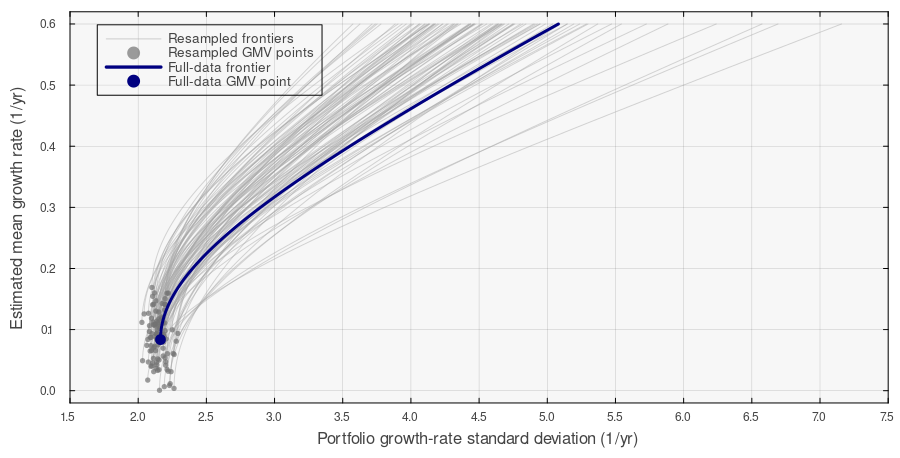

In [ ]:
let
    figure = plot();
    # Overlay all fitted curves, labeling only the first to avoid repeated legend entries.
    for (b, curve) ∈ enumerate(frontier_samples)
        plot!(figure, curve.σ, curve.g,
            color = :gray65, alpha = 0.45, linewidth = 1,
            label = b == 1 ? "Resampled frontiers" : "",
        );
    end
    # Entry 1 of each curve is its own GMV point; these markers need not share a mean growth.
    scatter!(figure,
        [curve.σ[1] for curve ∈ frontier_samples],
        [curve.g[1] for curve ∈ frontier_samples],
        color = :gray45, markersize = 3, markerstrokewidth = 0,
        alpha = 0.7, label = "Resampled GMV points",
    );
    plot!(figure, frontier_baseline.σ, frontier_baseline.g,
        color = :navy, linewidth = 3, label = "Full-data frontier",
    );
    scatter!(figure, [frontier_baseline.σ[1]], [frontier_baseline.g[1]],
        color = :navy, markersize = 6, markerstrokewidth = 0,
        label = "Full-data GMV point",
    );
    plot!(figure,
        xlabel = "Portfolio growth-rate standard deviation (1/yr)",
        ylabel = "Estimated mean growth rate (1/yr)",
        xlims = (1.5, 7.5), xticks = 1.5:0.5:7.5,
        ylims = (-0.02, 0.62), yticks = 0.0:0.1:0.6,
        legend = :topleft, legendfontsize = 9,
        size = (900, 460),
        left_margin = 5Plots.mm, bottom_margin = 5Plots.mm,
    )
end

For these data, the GMV standard deviation changes little across resamples,
while its estimated mean growth moves noticeably. The branches spread out
as the target increases. Both the estimated means and covariance change here;
we examine their separate effects later in this task.

Next, we compare the portfolio weights.


### Compare the long-only weights
How much does each firm's weight change across resamples? We compare the
long-only GMV weights with the long-only tangent grid candidates using
[the `boxplot(...)` function](https://docs.juliaplots.org/stable/generated/statsplots/#boxplot,-dotplot,-and-violin).

Each box spans the middle half of the weights, with a line at the median.
Whiskers reach the last values within 1.5 box heights below or above the box;
dots show the remaining values. Both panels use the same weight scale and
the ticker order from our data:


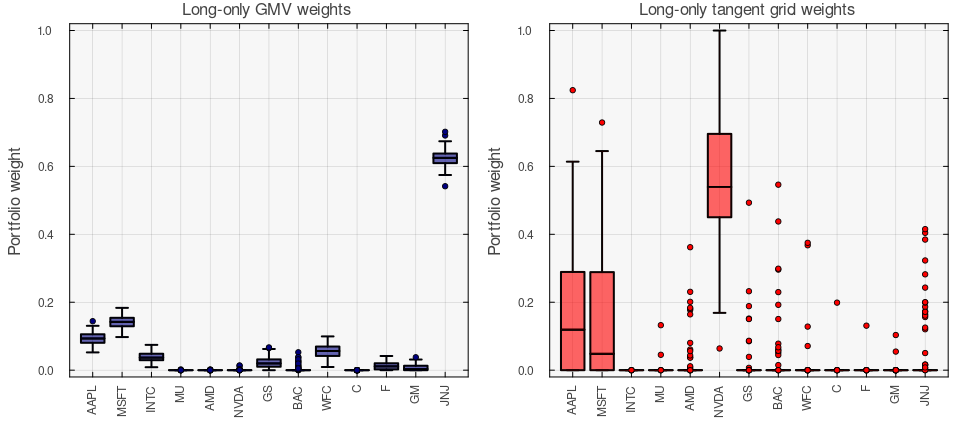

In [ ]:
let
    positions = repeat(1:M, inner = boot.B); # group resamples by asset index
    common = (
        legend = false,
        xticks = (1:M, my_list_of_tickers),
        xrotation = 90,
        ylims = (-0.02, 1.02),
        yticks = 0.0:0.2:1.0,
        titlefontsize = 11,
        fillalpha = 0.6,
        markershape = :circle,
        markersize = 3,
        whisker_range = 1.5,
    );
    # Transpose M × B weights to B × M before vec, which stacks columns in Julia.
    # This places all B resamples for asset 1 first, then asset 2, matching positions.
    p1 = boxplot(positions, vec(boot.gmv_long_only');
        common...,
        color = :navy,
        title = "Long-only GMV weights",
        ylabel = "Portfolio weight",
    );
    p2 = boxplot(positions, vec(boot.tan_long_only');
        common...,
        color = :red,
        title = "Long-only tangent grid weights",
        ylabel = "Portfolio weight",
    );
    plot(p1, p2,
        layout = (1, 2), size = (960, 440),
        bottom_margin = 8Plots.mm, left_margin = 5Plots.mm,
    )
end

For these data, the long-only GMV weights vary less than the tangent grid
weights. The tangent selection uses both the estimated means and covariance,
so changes in either input can shift the allocation.

### Measure the spread of the weights
To compare whole portfolios, we first find each asset's median weight across
resamples. For each method, let $w_i^{(b)}$ be asset $i$'s weight in resample
$b$. Its median weight is given by:
$$
\tilde{w}_i=\operatorname{median}_{b=1,\ldots,B} w_i^{(b)}.
$$
We then add the absolute differences from these medians:
$$
D_b=\sum_{i=1}^{M}\left|w_i^{(b)}-\tilde{w}_i\right|.
$$
Each method uses its own median weights. Larger $D_b$ means the allocation
is farther from that center. The median weights need not sum to one, so
$D_b$ measures __dispersion across estimates__, not trading turnover.

[The `distances(...)` function](docs/estimation-risk.md#distances) returns
the $B$ distances, and
[the `dispersion(...)` function](docs/estimation-risk.md#dispersion) averages
them. We store the mean and median distance, plus the largest absolute weight
across all firms and resamples, in `weight_dispersion::DataFrame`:


In [ ]:
weight_dispersion = let
    portfolios = [
        ("GMV (short positions allowed)", boot.gmv_closed),
        ("Normalized excess-growth weights", boot.tan_closed),
        ("GMV (long only)", boot.gmv_long_only),
        ("Tangent grid candidate (long only)", boot.tan_long_only),
    ];
    # Each method has its own componentwise median center, which need not sum to one.
    # Distances sum absolute weight differences across assets; they are dispersion, not turnover.
    # max_abs_w takes the largest absolute entry across all assets and all resamples.
    DataFrame(
        portfolio = [name for (name, W) ∈ portfolios],
        mean_dist = [dispersion(W) for (name, W) ∈ portfolios],
        median_dist = [median(distances(W)) for (name, W) ∈ portfolios],
        max_abs_w = [maximum(abs.(W)) for (name, W) ∈ portfolios],
    );
end;

All three measures are dimensionless. The normalized excess-growth row
includes every closed-form allocation, including those with negative
normalizers. Let's display the comparison:


In [ ]:
let
    table = copy(weight_dispersion); # round a display copy
    # Display the summaries together; rounding changes neither distances nor stored weights.
    table.mean_dist = round.(table.mean_dist, digits = 3);
    table.median_dist = round.(table.median_dist, digits = 3);
    table.max_abs_w = round.(table.max_abs_w, digits = 2);
    pretty_table(table,
        backend = :text,
        table_format = TextTableFormat(borders = text_table_borders__compact),
    )
end

 ------------------------------------ ----------- ------------- -----------
                           portfolio   mean_dist   median_dist   max_abs_w
                              String     Float64       Float64     Float64
 ------------------------------------ ----------- ------------- -----------
       GMV (short positions allowed)       0.206         0.197        0.68
    Normalized excess-growth weights      48.497         7.102      194.64
                     GMV (long only)        0.11         0.105         0.7
  Tangent grid candidate (long only)       0.572         0.533         1.0
 ------------------------------------ ----------- ------------- -----------


The long-only GMV weights have the smallest mean and median distances here.
The normalized closed-form weights have the largest spread. Large distances
pull their mean far above the median. Restricting weights to be long only reduces the spread for both
methods in this comparison.

Next, we check how the normalizing constant relates to the large closed-form
weights.


### Check the normalizing constant
Why can the closed-form weights become so large? They divide the excess-growth
direction by $\kappa$, so a small $|\kappa|$ can produce large weights.
The frontier coefficients give another expression for this normalizer:
$$
\kappa=b-a g_f=a\left(g_{\mathrm{GMV}}^{\prime}-g_f\right),
\qquad g_{\mathrm{GMV}}^{\prime}=\frac{b}{a}.
$$
Here $a>0$, so $\kappa$ has the same sign as the GMV portfolio's estimated
excess growth. It has units of years. We calculate it for the full training
data and each resample, storing both in `normalizers::NamedTuple`:


In [ ]:
normalizers = let
    # Solve Σ*x = g - g_f, then sum x; do not form an explicit inverse.
    # κ = a*(GMV mean - g_f), so its sign determines the direction after budget normalization.
    κ₀ = sum(Σ̂₀ \ (ĝ₀ .- g_f)); # full-data normalizer (years)
    κ = [
        sum(boot.Σ[b] \ (boot.ĝ[:, b] .- g_f)) for b ∈ 1:boot.B
    ]; # resampled normalizers (years)
    (baseline = κ₀, samples = κ);
end;

The full-data normalizer $\kappa_0$ is positive here. To flag small positive
values, we use $\kappa_0/10$ as a reference. This chosen cutoff does not
set the condition for a maximum-Sharpe portfolio; that condition is $\kappa>0$.
Let's count the resamples in each group:


In [ ]:
let
    κ₀ = normalizers.baseline;
    κ = normalizers.samples;
    # With positive κ₀ here, these three disjoint groups account for every resample.
    # κ₀/10 is a diagnostic cutoff, not a mathematical boundary for a tangent portfolio.
    table = DataFrame(
        condition = ["κ ≤ 0", "0 < κ < κ₀/10", "κ ≥ κ₀/10"],
        resamples = [
            count(κ .≤ 0),
            count(0 .< κ .< κ₀/10),
            count(κ .≥ κ₀/10),
        ],
    );
    println("Full-data normalizer: $(round(κ₀, digits = 4)) years");
    pretty_table(table,
        backend = :text,
        table_format = TextTableFormat(borders = text_table_borders__compact),
    )
end

Full-data normalizer: 0.0091 years
 --------------- -----------
      condition   resamples
         String       Int64
 --------------- -----------
          κ ≤ 0          15
  0 < κ < κ₀/10           2
      κ ≥ κ₀/10          83
 --------------- -----------


All 15 nonpositive normalizers are negative. Their normalized weights give
minimum-Sharpe portfolios, so they do not meet the condition for a tangent
portfolio. We retain them to show the formula's sensitivity. The two small
positive cases do give maximum-Sharpe portfolios, but dividing by a small
normalizer can produce large long and short positions.


### Vary one input at a time
Which input changes the weights more in this experiment? We use the same
100 resamples to vary the means while holding covariance fixed, then vary
covariance while holding the means fixed. Each fixed input uses the estimate
from all training data. We compare these results with the case where both
inputs vary.

[The `tangent_closed(...)` function](docs/estimation-risk.md#tangent_closed)
calculates the normalized weights, including cases with negative normalizers.
Each comparison uses its own median weight vector to calculate the distances
$D_b$. We store the mean and median distances in `input_dispersion::DataFrame`:


In [ ]:
input_dispersion = let
    # Reuse the original bootstrap draws, holding the other input at its full-training estimate.
    # hcat stores each returned weight vector as one column of an M × B matrix.
    W_means_only = hcat([
        tangent_closed(boot.ĝ[:, b], Σ̂₀, g_f) for b ∈ 1:boot.B
    ]...);
    W_cov_only = hcat([
        tangent_closed(ĝ₀, boot.Σ[b], g_f) for b ∈ 1:boot.B
    ]...);
    experiments = [
        ("Means and covariance resampled", boot.tan_closed),
        ("Means resampled, covariance fixed", W_means_only),
        ("Covariance resampled, means fixed", W_cov_only),
    ];
    # Each experiment uses its own median center; the three dispersions are not additive components.
    DataFrame(
        experiment = [name for (name, W) ∈ experiments],
        mean_dist = [dispersion(W) for (name, W) ∈ experiments],
        median_dist = [median(distances(W)) for (name, W) ∈ experiments],
    );
end;

Let's display the dimensionless distances. The first row repeats the
normalized closed-form result from the weight-dispersion table:


In [ ]:
let
    table = copy(input_dispersion); # round a display copy
    # Format the comparison without modifying the full-precision sensitivity results.
    table.mean_dist = round.(table.mean_dist, digits = 3);
    table.median_dist = round.(table.median_dist, digits = 3);
    pretty_table(table,
        backend = :text,
        table_format = TextTableFormat(borders = text_table_borders__compact),
    )
end

 ----------------------------------- ----------- -------------
                         experiment   mean_dist   median_dist
                             String     Float64       Float64
 ----------------------------------- ----------- -------------
     Means and covariance resampled      48.497         7.102
  Means resampled, covariance fixed      37.507         7.273
  Covariance resampled, means fixed        1.73         1.507
 ----------------------------------- ----------- -------------


Varying the means produces much larger mean and median distances than varying
covariance alone in this experiment. Both inputs affect the weights, but these
separate comparisons do not divide the total spread into additive parts.
We have not tested whether covariance shrinkage would reduce that spread.

Next, we compare the wealth paths from the long-only allocations on the
observed 2025 prices.

___


## Task 3: Compare Wealth on the 2025 Prices
How much do the different weights change realized wealth? We apply every
resampled long-only allocation to the same observed 2025 prices. We also
compare the GMV and tangent grid weights fitted to all training data, an
initially equal-weight portfolio, and SPY. The 2025 outcomes did not enter
the weight calculations.

### Calculate buy-and-hold wealth
For initial wealth $W_0$ and weights $w_i$, we buy $w_iW_0/S_i(0)$ shares of
firm $i$ at its first observed 2025 price. Holding these shares gives the
wealth ratio:
$$
R_t=\frac{W_t}{W_0}=\sum_{i=1}^{M}w_i\frac{S_i(t)}{S_i(0)}.
$$
Shares stay fixed, while weights change with prices. We allow fractional
shares and omit dividend cash flows, trading costs, and taxes. A terminal
ratio of $1.2$ means the holdings are worth 20% more than their initial value.
These ratios are not discounted.

We express each day's wealth change using continuous compounding. Over
interval $k$, wealth satisfies:
$$
W_k=W_{k-1}\exp\!\left(g_{W,k}\Delta t\right).
$$
Taking logs and solving for the interval's realized growth rate gives:
$$
g_{W,k}=\frac{1}{\Delta t}\ln\!\left(\frac{W_k}{W_{k-1}}\right).
$$
How do we write this using $R_k$? By definition, $R_k=W_k/W_0$, so
$W_k=W_0R_k$. The same initial wealth $W_0$ applies at both dates and cancels:
$$
\frac{W_k}{W_{k-1}}
=\frac{W_0R_k}{W_0R_{k-1}}
=\frac{R_k}{R_{k-1}}.
$$
Using the log rule $\ln(a/b)=\ln a-\ln b$, we obtain:
$$
\boxed{
g_{W,k}
=\frac{1}{\Delta t}\ln\!\left(\frac{R_k}{R_{k-1}}\right)
=\frac{\ln R_k-\ln R_{k-1}}{\Delta t},
\qquad k=1,\ldots,K
}.
$$
Scaling wealth by the fixed initial amount therefore leaves its growth rate
unchanged.
We calculate a separate rate for each daily interval. Here $K=249$ and
$\Delta t=1/252$ years. The sample standard deviation of these rates uses
the $K-1$ denominator and has units of inverse years.

[The `buy_and_hold_statistics(...)` function](docs/estimation-risk.md#buy_and_hold_statistics)
returns the wealth path, terminal ratio, and growth-rate standard deviation.
We store the last two measures for each allocation in `oos::DataFrame`:


In [ ]:
oos = let
    results = DataFrame(
        portfolio = String[], terminal_ratio = Float64[], σ_g_2025 = Float64[],
    );
    # Evaluate 2B resampled allocations on one common observed price history.
    # The helper divides each asset price by its initial price and multiplies by initial weights;
    # shares stay fixed. It also computes std(diff(log.(wealth_ratio))/Δt) across daily intervals.
    for b ∈ 1:boot.B
        for (name, w) ∈ [
            ("GMV, resampled", boot.gmv_long_only[:, b]),
            ("Tangent grid, resampled", boot.tan_long_only[:, b]),
        ]
            result = buy_and_hold_statistics(prices_2025, w, Δt);
            push!(results, (name, result.terminal_ratio, result.σ_g));
        end
    end
    # Add one result per full-training or equal-weight baseline, not B duplicate observations.
    for (name, w) ∈ [
        ("GMV, training fit", w_gmv₀),
        ("Tangent grid, training fit", w_tan₀),
        ("Equal weights", fill(1/M, M)),
    ]
        result = buy_and_hold_statistics(prices_2025, w, Δt);
        push!(results, (name, result.terminal_ratio, result.σ_g));
    end
    # Treat SPY as a one-asset portfolio: reshape supplies the matrix expected by the helper.
    result = buy_and_hold_statistics(reshape(spy_2025, :, 1), [1.0], Δt);
    push!(results, ("SPY", result.terminal_ratio, result.σ_g));
    results;
end;

### Summarize the outcomes
For each resampled method, we report the median terminal wealth ratio, its
5th and 95th percentiles, and the median growth-rate standard deviation.
These summaries describe 100 different allocations on one price history;
they are not intervals for future prices or wealth:


In [ ]:
wealth_summary = let
    # Exclude singleton baselines before grouping: quantiles summarize the B fitted allocations.
    # These ranges reflect weight sensitivity on fixed 2025 prices, not a future-wealth distribution.
    samples = filter(
        :portfolio => ∈(["GMV, resampled", "Tangent grid, resampled"]), oos,
    );
    # Each transformation maps one group to one scalar; the last symbol names its output column.
    combine(groupby(samples, :portfolio, sort = true),
        :terminal_ratio => median => :median_ratio,
        :terminal_ratio => (x -> quantile(x, 0.05)) => :q05_ratio,
        :terminal_ratio => (x -> quantile(x, 0.95)) => :q95_ratio,
        :σ_g_2025 => median => :median_σ_g,
    );
end;

The wealth ratios are dimensionless; `median_σ_g` has units of inverse years.
Let's display the two resampled groups:


In [ ]:
let
    table = copy(wealth_summary); # round a display copy
    # Round the copy for display; the summary remains available at full precision.
    for column ∈ [:median_ratio, :q05_ratio, :q95_ratio, :median_σ_g]
        table[!, column] = round.(table[!, column], digits = 3);
    end
    pretty_table(table,
        backend = :text,
        table_format = TextTableFormat(borders = text_table_borders__compact),
    )
end

 ------------------------- -------------- ----------- ----------- ------------
                portfolio   median_ratio   q05_ratio   q95_ratio   median_σ_g
                   String        Float64     Float64     Float64      Float64
 ------------------------- -------------- ----------- ----------- ------------
           GMV, resampled          1.374       1.362       1.394        1.992
  Tangent grid, resampled          1.294       1.213        1.44        4.527
 ------------------------- -------------- ----------- ----------- ------------


The GMV terminal ratios have a much narrower span between the 5th and 95th
percentiles. Next, we show the four baseline portfolios. Each has one outcome
on this price history, so we report its terminal ratio and growth-rate
standard deviation directly:


In [ ]:
let
    # Each selected baseline has one observed outcome, so report it directly without quantiles.
    # filter returns a separate table; display rounding leaves oos unchanged.
    table = filter(
        :portfolio => ∈(["GMV, training fit", "Tangent grid, training fit",
            "Equal weights", "SPY"]), oos,
    );
    table.terminal_ratio = round.(table.terminal_ratio, digits = 3);
    table.σ_g_2025 = round.(table.σ_g_2025, digits = 3);
    pretty_table(table,
        backend = :text,
        table_format = TextTableFormat(borders = text_table_borders__compact),
    )
end

 ---------------------------- ---------------- ----------
                   portfolio   terminal_ratio   σ_g_2025
                      String          Float64    Float64
 ---------------------------- ---------------- ----------
           GMV, training fit            1.377      1.996
  Tangent grid, training fit            1.288      5.025
               Equal weights            1.592      3.487
                         SPY            1.169      2.206
 ---------------------------- ---------------- ----------


### How much does terminal wealth change across fitted weights?
To see the effect of changing the weights, we compare the terminal wealth
ratios of the 100 resampled GMV allocations and 100 tangent grid candidates.
Every allocation uses the same observed 2025 prices.

Each horizontal box spans the middle half of the ratios, with a line at the
median. Whiskers reach the last values within 1.5 box widths of the box;
dots show values beyond them. A black filled circle marks the allocation
fitted to all training data:


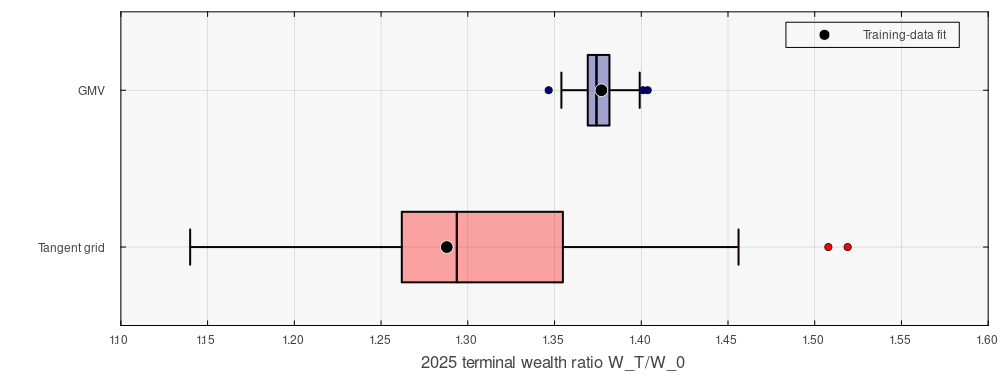

In [ ]:
let
    # Horizontal boxes summarize 100 terminal ratios per method on the same 2025 prices.
    p = plot();
    for (position, name, color) ∈ [
        (2, "GMV, resampled", :navy),
        (1, "Tangent grid, resampled", :red),
    ]
        rows = filter(:portfolio => ==(name), oos);
        boxplot!(p, fill(position, nrow(rows)), rows.terminal_ratio,
            orientation = :horizontal, bar_width = 0.45,
            color = color, fillalpha = 0.35, whisker_range = 1.5,
            markershape = :circle, markersize = 4, label = "",
        );
    end
    for (position, name) ∈ [
        (2, "GMV, training fit"),
        (1, "Tangent grid, training fit"),
    ]
        # only requires exactly one matching baseline; place that outcome on its method's row.
        row = only(filter(:portfolio => ==(name), oos).terminal_ratio);
        scatter!(p, [row], [position],
            markershape = :circle, markersize = 7, color = :black,
            markerstrokecolor = :white, markerstrokewidth = 1,
            label = position == 2 ? "Training-data fit" : "",
        );
    end
    plot!(p,
        xlabel = "2025 terminal wealth ratio W_T/W_0",
        yticks = ([1, 2], ["Tangent grid", "GMV"]), ylims = (0.5, 2.5),
        xlims = (1.1, 1.6), xticks = 1.1:0.05:1.6,
        legend = :topright, size = (1000, 380),
        left_margin = 8Plots.mm, bottom_margin = 6Plots.mm,
    )
end

The GMV allocations give similar terminal wealth ratios across resamples.
The tangent grid candidates give a much wider spread. Thus, re-estimating
the weights changes the tangent portfolio's 2025 wealth more in this example.

This spread comes from different fitted weights on one observed price
history. It does not describe the range of wealth we should expect in a
future year.

___


## Summary

In this example, we used bootstrap resampling to estimate uncertainty in
portfolio inputs, compare GMV and tangent weights, and evaluate the resulting
long-only allocations on 2025 prices.

> __Key Takeaways:__
>
> - **Input uncertainty:** We resampled complete days to estimate standard errors while keeping the firms' same-day growth rates together. For many firms, the mean estimates were much less precise relative to their size than the standard-deviation estimates. These results rely on treating different days as independent.
>
> - **Weight sensitivity:** We found less variation in GMV weights, and long-only constraints reduced dispersion in this comparison. Varying the means alone produced more spread in normalized closed-form weights than varying covariance alone. The normalizer's sign distinguished maximum-Sharpe from minimum-Sharpe solutions.
>
> - **Wealth on the observed prices:** We applied every resampled long-only allocation to the same 2025 prices. GMV portfolios gave similar terminal wealth ratios, while tangent grid candidates gave a wider spread. This showed how changing the fitted weights affected wealth on that history; it did not give an interval for future wealth.

Next, [L6a](../../../../week-6/L6a/CHEME-5660-L6a-Lecture-SIM-Fall-2026.ipynb)
replaces separate pairwise covariance estimates with a model driven by one
market index. We reduce the number of parameters to estimate and check
whether the assets still move together after the market effect is removed.

___


## Disclaimer and Risks
__This content is offered solely for training and informational purposes__. No offer or solicitation to buy or sell securities or derivative products or any investment or trading advice or strategy is made, given, or endorsed by the teaching team. 

__Trading involves risk__. Carefully review your financial situation before investing in securities, futures contracts, options, or commodity interests. Past performance, whether actual or indicated by historical tests of strategies, is no guarantee of future performance or success. Trading is generally inappropriate for someone with limited resources, investment or trading experience, or a low-risk tolerance. Only risk capital that is not required for living expenses should be used.

__You are fully responsible for any investment or trading decisions you make__. Such decisions should be based solely on evaluating your financial circumstances, investment or trading objectives, risk tolerance, and liquidity needs.
